# Random Forest with Google Trends — Polymarket ML

**Course:** DS-GA 1003 | NYU  
**Team:** Dhairya Dhamani, Hector Thompson Baroni, Sachin Sastri

Mirrors `models/random_forest/random_forest.ipynb` but trains on the enriched dataset that includes 5 Google Trends features (weekly category-level search interest). Directly comparable to the original RF results.

**Research questions:**
- **RQ1:** Does the market price alone remain the strongest signal?
- **RQ2:** Do Google Trends features add value beyond price + engineered features?
- **RQ3:** At which lifecycle stage do trend features provide the most lift?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.preprocessing import OrdinalEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

try:
    from cuml.ensemble import RandomForestClassifier
    print("cuML RandomForestClassifier loaded — using GPU")
    GPU = True
except ImportError:
    from sklearn.ensemble import RandomForestClassifier
    print("cuML not found — falling back to sklearn CPU")
    GPU = False

ROOT     = Path("../../")
PART1    = ROOT / "data" / "polymarket_ml_dataset_with_trends_part1.parquet"
PART2    = ROOT / "data" / "polymarket_ml_dataset_with_trends_part2.parquet"
ART_DIR  = Path("artifacts")
PRED_DIR = Path("predictions")
ART_DIR.mkdir(exist_ok=True)
PRED_DIR.mkdir(exist_ok=True)

cuML not found — falling back to sklearn CPU


## 1. Load Data

In [3]:
df = pd.concat([pd.read_parquet(PART1), pd.read_parquet(PART2)], ignore_index=True)
print(f"Total rows: {len(df):,}  |  Columns: {df.shape[1]}")

train = df[df["split"] == "train"].copy()
test  = df[df["split"] == "test"].copy()

# Leakage check
overlap = set(train["market_id"]) & set(test["market_id"])
assert len(overlap) == 0, f"Leakage: {len(overlap)} shared market IDs"

print(f"Train: {len(train):,} rows | {train['market_id'].nunique():,} markets | YES rate: {train['outcome'].mean():.3f}")
print(f"Test:  {len(test):,} rows  | {test['market_id'].nunique():,} markets  | YES rate: {test['outcome'].mean():.3f}")
print("Leakage check passed — zero market overlap between train and test")

Total rows: 4,078,109  |  Columns: 32
Train: 3,268,545 rows | 17,073 markets | YES rate: 0.171
Test:  809,564 rows  | 4,243 markets  | YES rate: 0.162
Leakage check passed — zero market overlap between train and test


## 2. Feature Engineering

In [4]:
# Category encoding
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
enc.fit(train[["category"]])
train["category_encoded"] = enc.transform(train[["category"]]).astype("float32")
test["category_encoded"]  = enc.transform(test[["category"]]).astype("float32")

FEATURES_PRICE_ONLY = ["price_at_snapshot"]

FEATURES_FULL = [
    "price_at_snapshot", "price_deviation_from_half",
    "price_mean_7d",  "price_volatility_7d",  "price_min_7d",  "price_max_7d",
    "price_change_7d",  "price_range_7d",  "price_trend_7d",
    "price_mean_14d", "price_volatility_14d", "price_min_14d", "price_max_14d",
    "price_change_14d", "price_range_14d", "price_trend_14d",
    "pct_lifetime_elapsed", "days_before_close", "duration_days",
    "log_volume", "category_encoded",
]

FEATURES_TRENDS = FEATURES_FULL + [
    "trend_value", "trend_ma4", "trend_change_4w", "trend_spike", "has_trend_data",
]

# Train / calibration split (market-level 80/20)
rng     = np.random.RandomState(42)
all_ids = train["market_id"].unique()
cal_ids = set(rng.choice(all_ids, size=int(len(all_ids) * 0.2), replace=False))

train_fit = train[~train["market_id"].isin(cal_ids)].copy()
train_cal = train[train["market_id"].isin(cal_ids)].copy()

print(f"train_fit: {len(train_fit):,} rows | {train_fit['market_id'].nunique():,} markets")
print(f"train_cal: {len(train_cal):,} rows | {train_cal['market_id'].nunique():,} markets")

# Numpy arrays
X_fit_price  = train_fit[FEATURES_PRICE_ONLY].values.astype("float32")
X_fit_full   = train_fit[FEATURES_FULL].values.astype("float32")
X_fit_trends = train_fit[FEATURES_TRENDS].values.astype("float32")
y_fit        = train_fit["outcome"].values.astype("int32")

X_cal_trends = train_cal[FEATURES_TRENDS].values.astype("float32")
y_cal        = train_cal["outcome"].values.astype("int32")

X_test_price  = test[FEATURES_PRICE_ONLY].values.astype("float32")
X_test_full   = test[FEATURES_FULL].values.astype("float32")
X_test_trends = test[FEATURES_TRENDS].values.astype("float32")
y_test        = test["outcome"].values.astype("int32")

sample_weights = compute_sample_weight("balanced", y_fit).astype("float32")
print(f"\nClass weight ratio (NO:YES) = {sample_weights[y_fit==0].mean():.3f} : {sample_weights[y_fit==1].mean():.3f}")

train_fit: 2,605,753 rows | 13,659 markets
train_cal: 662,792 rows | 3,414 markets

Class weight ratio (NO:YES) = 0.603 : 2.937


## 3. Market Price Baseline

In [5]:
baseline_proba = test["price_at_snapshot"].values.clip(1e-6, 1 - 1e-6)

baseline_auc    = roc_auc_score(y_test, baseline_proba)
baseline_ll     = log_loss(y_test, baseline_proba)
baseline_brier  = brier_score_loss(y_test, baseline_proba)

print("Market Price Baseline (test set)")
print(f"  AUC-ROC:     {baseline_auc:.4f}")
print(f"  Log-loss:    {baseline_ll:.4f}")
print(f"  Brier Score: {baseline_brier:.4f}")

Market Price Baseline (test set)
  AUC-ROC:     0.9674
  Log-loss:    0.1633
  Brier Score: 0.0478


## 4. 5-Fold Cross-Validation (rf_trends features)

In [6]:
cv_params = dict(
    n_estimators=100,
    max_depth=16,
    random_state=42,
)
if not GPU:
    cv_params.update(min_samples_leaf=50, max_features="sqrt", n_jobs=-1)

sgkf   = StratifiedGroupKFold(n_splits=5)
groups = train_fit["market_id"].values
cv_auc = []

for fold, (tr_idx, val_idx) in enumerate(sgkf.split(X_fit_trends, y_fit, groups=groups), 1):
    clf = RandomForestClassifier(**cv_params)
    clf.fit(X_fit_trends[tr_idx], y_fit[tr_idx], sample_weight=sample_weights[tr_idx])
    proba = clf.predict_proba(X_fit_trends[val_idx])[:, 1]
    auc   = roc_auc_score(y_fit[val_idx], proba)
    cv_auc.append(auc)
    print(f"  Fold {fold}: AUC-ROC = {auc:.4f}")

print(f"\nCV Mean: {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}")
print(f"Baseline: {baseline_auc:.4f}")

  Fold 1: AUC-ROC = 0.9628
  Fold 2: AUC-ROC = 0.9648
  Fold 3: AUC-ROC = 0.9691
  Fold 4: AUC-ROC = 0.9670
  Fold 5: AUC-ROC = 0.9675

CV Mean: 0.9662 ± 0.0022
Baseline: 0.9674


## 5. Train Final Models

In [7]:
final_params = dict(
    n_estimators=300,
    max_depth=16,
    random_state=42,
)
if not GPU:
    final_params.update(min_samples_leaf=50, max_features="sqrt", n_jobs=-1)

print("Training rf_price_only...")
rf_price_only = RandomForestClassifier(**final_params)
rf_price_only.fit(X_fit_price, y_fit, sample_weight=sample_weights)
joblib.dump(rf_price_only, ART_DIR / "trends_rf_price_only.pkl")
print("  Saved trends_rf_price_only.pkl")

print("Training rf_full...")
rf_full = RandomForestClassifier(**final_params)
rf_full.fit(X_fit_full, y_fit, sample_weight=sample_weights)
joblib.dump(rf_full, ART_DIR / "trends_rf_full.pkl")
print("  Saved trends_rf_full.pkl")

print("Training rf_trends...")
rf_trends = RandomForestClassifier(**final_params)
rf_trends.fit(X_fit_trends, y_fit, sample_weight=sample_weights)
joblib.dump(rf_trends, ART_DIR / "trends_rf_trends.pkl")
print("  Saved trends_rf_trends.pkl")

print("Calibrating rf_trends (isotonic regression on train_cal)...")
rf_trends_calibrated = CalibratedClassifierCV(rf_trends, method="isotonic", cv="prefit")
rf_trends_calibrated.fit(X_cal_trends, y_cal)
joblib.dump(rf_trends_calibrated, ART_DIR / "trends_rf_trends_calibrated.pkl")
print("  Saved trends_rf_trends_calibrated.pkl")

print("\nAll models trained and saved.")

Training rf_price_only...
  Saved trends_rf_price_only.pkl
Training rf_full...
  Saved trends_rf_full.pkl
Training rf_trends...
  Saved trends_rf_trends.pkl
Calibrating rf_trends (isotonic regression on train_cal)...


c:\Users\Owner\miniconda3\envs\myenv\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


  Saved trends_rf_trends_calibrated.pkl

All models trained and saved.


## 6. Test Set Evaluation

In [8]:
proba_price = rf_price_only.predict_proba(X_test_price)[:, 1]
proba_full  = rf_full.predict_proba(X_test_full)[:, 1]
proba_tr    = rf_trends.predict_proba(X_test_trends)[:, 1]
proba_tr_cal = rf_trends_calibrated.predict_proba(X_test_trends)[:, 1]

results = {
    "Market Baseline":        (baseline_proba,),
    "RF Price-Only":          (proba_price,),
    "RF Full (21 features)":  (proba_full,),
    "RF Trends (26 features)":(proba_tr,),
    "RF Trends Calibrated":   (proba_tr_cal,),
}

print(f"{'Model':<30} {'AUC-ROC':>8} {'Log-loss':>10} {'Brier':>8} {'ΔAUC':>8} {'ΔLL':>8}")
print("-" * 80)
for name, (p,) in results.items():
    auc   = roc_auc_score(y_test, p)
    ll    = log_loss(y_test, p)
    brier = brier_score_loss(y_test, p)
    d_auc = auc - baseline_auc
    d_ll  = ll  - baseline_ll
    print(f"{name:<30} {auc:>8.4f} {ll:>10.4f} {brier:>8.4f} {d_auc:>+8.4f} {d_ll:>+8.4f}")

Model                           AUC-ROC   Log-loss    Brier     ΔAUC      ΔLL
--------------------------------------------------------------------------------
Market Baseline                  0.9674     0.1633   0.0478  +0.0000  +0.0000
RF Price-Only                    0.9678     0.2269   0.0689  +0.0004  +0.0637
RF Full (21 features)            0.9693     0.1871   0.0556  +0.0019  +0.0239
RF Trends (26 features)          0.9711     0.1820   0.0544  +0.0037  +0.0187
RF Trends Calibrated             0.9710     0.1484   0.0435  +0.0035  -0.0149


## 7. ROC Curve

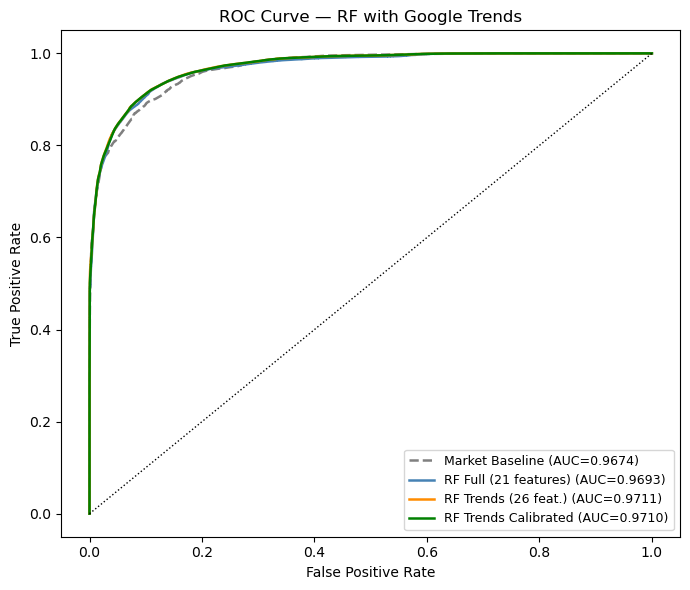

In [9]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 6))

plot_models = [
    ("Market Baseline",       baseline_proba, "gray",       "--"),
    ("RF Full (21 features)", proba_full,     "steelblue",  "-"),
    ("RF Trends (26 feat.)",  proba_tr,       "darkorange", "-"),
    ("RF Trends Calibrated",  proba_tr_cal,   "green",      "-"),
]

for label, p, color, ls in plot_models:
    fpr, tpr, _ = roc_curve(y_test, p)
    auc = roc_auc_score(y_test, p)
    ax.plot(fpr, tpr, color=color, ls=ls, lw=1.8, label=f"{label} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], "k:", lw=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — RF with Google Trends")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ART_DIR / "trends_roc_curve.png", dpi=150)
plt.show()

## 8. Calibration Curve

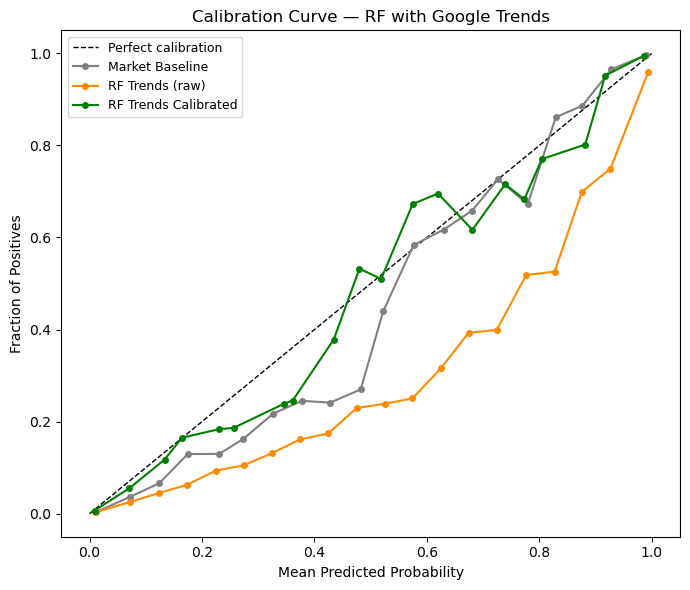

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")

for label, p, color in [
    ("Market Baseline",      baseline_proba, "gray"),
    ("RF Trends (raw)",      proba_tr,       "darkorange"),
    ("RF Trends Calibrated", proba_tr_cal,   "green"),
]:
    fraction_pos, mean_pred = calibration_curve(y_test, p, n_bins=20)
    ax.plot(mean_pred, fraction_pos, "o-", color=color, lw=1.5, ms=4, label=label)

ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.set_title("Calibration Curve — RF with Google Trends")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(ART_DIR / "trends_calibration.png", dpi=150)
plt.show()

## 9. Feature Importance (RQ2)

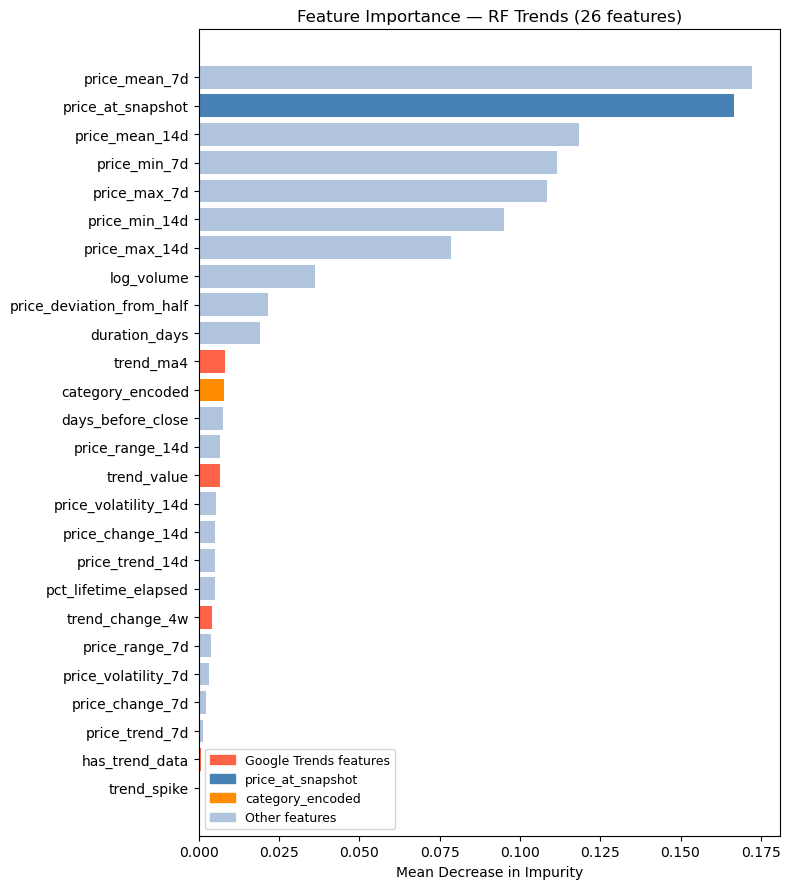


Top 10 features:
                  feature  importance
            price_mean_7d    0.172363
        price_at_snapshot    0.166739
           price_mean_14d    0.118359
             price_min_7d    0.111383
             price_max_7d    0.108420
            price_min_14d    0.095148
            price_max_14d    0.078545
               log_volume    0.036162
price_deviation_from_half    0.021407
            duration_days    0.019014


In [11]:
TREND_FEATURE_NAMES = {"trend_value", "trend_ma4", "trend_change_4w", "trend_spike", "has_trend_data"}

importances = rf_trends.feature_importances_
feat_df = pd.DataFrame({"feature": FEATURES_TRENDS, "importance": importances})
feat_df = feat_df.sort_values("importance")

colors = [
    "tomato"     if f in TREND_FEATURE_NAMES else
    "steelblue"  if f == "price_at_snapshot" else
    "darkorange" if f == "category_encoded"  else
    "lightsteelblue"
    for f in feat_df["feature"]
]

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(feat_df["feature"], feat_df["importance"], color=colors)

from matplotlib.patches import Patch
legend_els = [
    Patch(color="tomato",       label="Google Trends features"),
    Patch(color="steelblue",    label="price_at_snapshot"),
    Patch(color="darkorange",   label="category_encoded"),
    Patch(color="lightsteelblue", label="Other features"),
]
ax.legend(handles=legend_els, fontsize=9)
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_title("Feature Importance — RF Trends (26 features)")
plt.tight_layout()
plt.savefig(ART_DIR / "trends_feature_importance.png", dpi=150)
plt.show()

print("\nTop 10 features:")
print(feat_df.sort_values("importance", ascending=False).head(10).to_string(index=False))

## 10. Lifecycle AUC Analysis (RQ3)

Stage               Snapshots   RF Trends Cal AUC   Baseline AUC    Delta
---------------------------------------------------------------------------
Early (0-33%)         226,832              0.9505         0.9426  +0.0079
Mid (33-67%)          346,681              0.9679         0.9636  +0.0043
Late (67-100%)        236,051              0.9885         0.9883  +0.0003


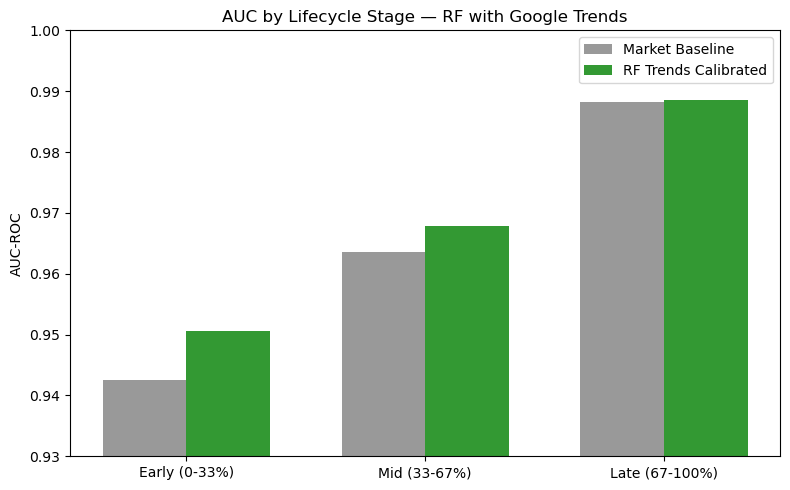

In [12]:
test_eval = test.copy()
test_eval["proba_tr_cal"] = proba_tr_cal
test_eval["proba_baseline"] = baseline_proba
test_eval["lifecycle"] = pd.cut(
    test_eval["pct_lifetime_elapsed"],
    bins=[0, 0.33, 0.67, 1.0],
    labels=["Early (0-33%)", "Mid (33-67%)", "Late (67-100%)"]
)

print(f"{'Stage':<18} {'Snapshots':>10} {'RF Trends Cal AUC':>19} {'Baseline AUC':>14} {'Delta':>8}")
print("-" * 75)

stage_data = []
for stage in ["Early (0-33%)", "Mid (33-67%)", "Late (67-100%)"]:
    mask = test_eval["lifecycle"] == stage
    sub  = test_eval[mask]
    if sub["outcome"].nunique() < 2:
        continue
    auc_rf  = roc_auc_score(sub["outcome"], sub["proba_tr_cal"])
    auc_bl  = roc_auc_score(sub["outcome"], sub["proba_baseline"])
    delta   = auc_rf - auc_bl
    stage_data.append((stage, len(sub), auc_rf, auc_bl, delta))
    print(f"{stage:<18} {len(sub):>10,} {auc_rf:>19.4f} {auc_bl:>14.4f} {delta:>+8.4f}")

# Plot
stages  = [s[0] for s in stage_data]
auc_rfs = [s[2] for s in stage_data]
auc_bls = [s[3] for s in stage_data]
x = np.arange(len(stages))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, auc_bls, w, label="Market Baseline", color="gray",  alpha=0.8)
ax.bar(x + w/2, auc_rfs, w, label="RF Trends Calibrated", color="green", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.set_ylabel("AUC-ROC")
ax.set_title("AUC by Lifecycle Stage — RF with Google Trends")
ax.legend()
ax.set_ylim(0.93, 1.0)
plt.tight_layout()
plt.savefig(ART_DIR / "trends_lifecycle_auc.png", dpi=150)
plt.show()

## 11. Save Predictions

In [13]:
# Train fit predictions
p_fit_price = rf_price_only.predict_proba(X_fit_price)[:, 1]
p_fit_full  = rf_full.predict_proba(X_fit_full)[:, 1]
p_fit_tr    = rf_trends.predict_proba(X_fit_trends)[:, 1]
p_fit_tr_cal = rf_trends_calibrated.predict_proba(X_fit_trends)[:, 1]

train_preds = train_fit[["market_id", "snapshot_timestamp", "outcome", "split"]].copy()
train_preds["proba_price_only"]        = p_fit_price.round(6)
train_preds["proba_full"]              = p_fit_full.round(6)
train_preds["proba_trends"]            = p_fit_tr.round(6)
train_preds["proba_trends_calibrated"] = p_fit_tr_cal.round(6)
train_preds.to_csv(PRED_DIR / "trends_train_predictions.csv", index=False)
print(f"Saved trends_train_predictions.csv ({len(train_preds):,} rows)")

# Val (calibration holdout) predictions
X_cal_price = train_cal[FEATURES_PRICE_ONLY].values.astype("float32")
X_cal_full  = train_cal[FEATURES_FULL].values.astype("float32")

p_cal_price  = rf_price_only.predict_proba(X_cal_price)[:, 1]
p_cal_full   = rf_full.predict_proba(X_cal_full)[:, 1]
p_cal_tr     = rf_trends.predict_proba(X_cal_trends)[:, 1]
p_cal_tr_cal = rf_trends_calibrated.predict_proba(X_cal_trends)[:, 1]

val_preds = train_cal[["market_id", "snapshot_timestamp", "outcome", "split"]].copy()
val_preds["proba_price_only"]        = p_cal_price.round(6)
val_preds["proba_full"]              = p_cal_full.round(6)
val_preds["proba_trends"]            = p_cal_tr.round(6)
val_preds["proba_trends_calibrated"] = p_cal_tr_cal.round(6)
val_preds.to_csv(PRED_DIR / "trends_val_predictions.csv", index=False)
print(f"Saved trends_val_predictions.csv ({len(val_preds):,} rows)")

# Test predictions
test_preds = test[["market_id", "snapshot_timestamp", "outcome", "split"]].copy()
test_preds["proba_price_only"]        = proba_price.round(6)
test_preds["proba_full"]              = proba_full.round(6)
test_preds["proba_trends"]            = proba_tr.round(6)
test_preds["proba_trends_calibrated"] = proba_tr_cal.round(6)
test_preds.to_csv(PRED_DIR / "trends_test_predictions.csv", index=False)
print(f"Saved trends_test_predictions.csv ({len(test_preds):,} rows)")

Saved trends_train_predictions.csv (2,605,753 rows)
Saved trends_val_predictions.csv (662,792 rows)
Saved trends_test_predictions.csv (809,564 rows)


## 12. Summary

In [14]:
print("=" * 80)
print("FINAL RESULTS — RF with Google Trends")
print("=" * 80)
print(f"{'Model':<30} {'AUC-ROC':>8} {'Log-loss':>10} {'Brier':>8}")
print("-" * 60)
for name, p in [
    ("Market Baseline",        baseline_proba),
    ("RF Price-Only",          proba_price),
    ("RF Full (21 features)",  proba_full),
    ("RF Trends (26 features)",proba_tr),
    ("RF Trends Calibrated",   proba_tr_cal),
]:
    print(f"{name:<30} {roc_auc_score(y_test,p):>8.4f} {log_loss(y_test,p):>10.4f} {brier_score_loss(y_test,p):>8.4f}")

print("\nArtifacts saved:")
for f in sorted(ART_DIR.glob("*")):
    print(f"  {f}")
print("\nPredictions saved:")
for f in sorted(PRED_DIR.glob("*.csv")):
    print(f"  {f}")

FINAL RESULTS — RF with Google Trends
Model                           AUC-ROC   Log-loss    Brier
------------------------------------------------------------
Market Baseline                  0.9674     0.1633   0.0478
RF Price-Only                    0.9678     0.2269   0.0689
RF Full (21 features)            0.9693     0.1871   0.0556
RF Trends (26 features)          0.9711     0.1820   0.0544
RF Trends Calibrated             0.9710     0.1484   0.0435

Artifacts saved:
  artifacts\trends_calibration.png
  artifacts\trends_feature_importance.png
  artifacts\trends_lifecycle_auc.png
  artifacts\trends_rf_full.pkl
  artifacts\trends_rf_price_only.pkl
  artifacts\trends_rf_trends.pkl
  artifacts\trends_rf_trends_calibrated.pkl
  artifacts\trends_roc_curve.png

Predictions saved:
  predictions\trends_test_predictions.csv
  predictions\trends_train_predictions.csv
  predictions\trends_val_predictions.csv


In [15]:

import pandas as pd
import numpy as np

# Load test predictions
test_df = pd.read_csv(r'C:\Users\Owner\predicting-the-future\models\random_forest_trends\predictions\trends_test_predictions.csv')

print("=" * 80)
print("TRENDS_TEST_PREDICTIONS.CSV")
print("=" * 80)
print(f"\nShape: {test_df.shape}")
print(f"Column names: {list(test_df.columns)}")
print(f"\nDtypes:\n{test_df.dtypes}")
print(f"\nFirst 5 rows:")
print(test_df.head(5).to_string())
print(f"\nOutcome distribution (0/1):")
print(test_df['outcome'].value_counts().sort_index())
print(f"Outcome proportions: {test_df['outcome'].value_counts(normalize=True).sort_index().to_dict()}")

print(f"\n--- proba_trends_calibrated statistics ---")
col = test_df['proba_trends_calibrated']
print(f"Min:    {col.min():.6f}")
print(f"Max:    {col.max():.6f}")
print(f"Mean:   {col.mean():.6f}")
print(f"Std:    {col.std():.6f}")
print(f"Median: {col.median():.6f}")
print(f"\nPercentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  {p}th:  {col.quantile(p/100):.6f}")


TRENDS_TEST_PREDICTIONS.CSV

Shape: (809564, 8)
Column names: ['market_id', 'snapshot_timestamp', 'outcome', 'split', 'proba_price_only', 'proba_full', 'proba_trends', 'proba_trends_calibrated']

Dtypes:
market_id                   object
snapshot_timestamp          object
outcome                      int64
split                       object
proba_price_only           float64
proba_full                 float64
proba_trends               float64
proba_trends_calibrated    float64
dtype: object

First 5 rows:
                                                            market_id                snapshot_timestamp  outcome split  proba_price_only  proba_full  proba_trends  proba_trends_calibrated
0  0xf8644ffe668cfec9044c2b64f9825ffce8520b521df526f155015fc2cbcbfc3a  2023-03-09 21:08:18.864000+00:00        0  test          0.792751    0.639955      0.556817                 0.351674
1  0xf8644ffe668cfec9044c2b64f9825ffce8520b521df526f155015fc2cbcbfc3a  2023-03-10 09:08:18.864000+00:00        